## Анализ графов коммуникации в задачах децентрализованной оптимизации

### Зачем здесь графы и «сложные сети»?

В статье **“Complexity of Decentralized Optimization with Mixed Affine Constraints”**
показывается, что **сложность децентрализованной оптимизации**
зависит не только от свойств целевой функции,
но и от **структуры коммуникации между агентами**.

**Коммуникационная структура** моделируется графом

$$
G = (V, E),
$$

где  
- **вершины** — это *агенты* (клиенты, устройства, вычислительные узлы),  
- **рёбра** — это *разрешённые каналы обмена информацией*.

Во всех алгоритмах статьи передача информации между агентами
происходит **только вдоль рёбер этого графа**.

> **Ключевая идея:**  
> одна и та же задача оптимизации может сходиться
> **быстро или медленно** исключительно из-за того,
> как устроен граф коммуникации.

---

### Как граф входит в оценки сложности?

В децентрализованных алгоритмах из статьи
коммуникационная структура задаётся **графом связи**,
а влияние сети на сложность алгоритма описывается
через **лапласиан этого графа**.

Обозначим через $$L$$ лапласиан графа коммуникации.
Его спектральные свойства напрямую входят
в оценки сходимости и коммуникационной сложности.

Ключевая величина — **spectral gap лапласиана**:

$$
\lambda_2(L),
$$

то есть **вторая собственная величина лапласиана**.

**Интерпретация spectral gap:**
- большая $$\lambda_2(L)$$ → информация быстро распространяется по сети,
- маленькая $$\lambda_2(L)$$ → согласование (consensus) между агентами происходит медленно.

Во многих оценках сложности из статьи
число итераций и коммуникационных раундов
обратно пропорционально $$\lambda_2(L)$$
(или эквивалентно зависит от числа обусловленности сети).

Таким образом, топология графа коммуникации
напрямую влияет на эффективность децентрализованных алгоритмов.


### Какие графы рассматриваются и почему?

Для иллюстрации влияния топологии сети
рассматриваются несколько стандартных типов графов:

1. **Кольцо (Ring)**  
   *Минимальная связность.*  
   Используется как **наихудший базовый случай**.

2. **Решётка (Grid)**  
   *Регулярная локальная структура.*  
   Типична для пространственно распределённых систем.

3. **Случайный граф Эрдёша–Реньи (ER)**  
   *Случайные связи между узлами.*  
   Обычно обладает **хорошими спектральными свойствами**.

4. **Scale-free граф (Barabási–Albert)**  
   *Наличие хабов.*  
   Модель реальных сетей (интернет, социальные сети).

5. **Small-world граф (Watts–Strogatz)**  
   *Короткие пути + локальные связи.*  
   Компромисс между регулярностью и случайностью.

**Во всех экспериментах число вершин одинаково**,  
чтобы сравнение было корректным.

---

### Какие сетевые характеристики вычисляются?

Для каждого графа считаются следующие величины:

| Термин | Определение | Зачем нужен |
|------|------------|-------------|
| **Диаметр** | Максимальное расстояние между узлами | Оценивает «худший случай» передачи информации |
| **Средняя длина пути** | Среднее расстояние между всеми парами | Характеризует типичную скорость обмена |
| **$$\lambda_2$$** | Spectral gap лапласиана | Определяет скорость consensus |
| **$$\kappa_W$$** | Число обусловленности графа | Входит в оценки сложности алгоритмов |

---

### Что даёт этот анализ?

Этот блок является **подготовительным**.
Он нужен для того, чтобы:

- связать **абстрактные параметры сложности** из статьи
  с **конкретными графами коммуникации**;
- понять, какие топологии являются
  **благоприятными** или **неблагоприятными** для децентрализованных алгоритмов;
- подготовить основу для дальнейших экспериментов,
  где **одна и та же задача (P)** будет решаться
  при разных графах коммуникации.

В следующих ячейках эти сетевые характеристики
будут вычислены численно и использованы
для анализа сходимости алгоритмов.


Сравнение характеристик графов коммуникации (n=60):

Граф                         |   D |     L̄ |         λ₂ | рёбра
----------------------------------------------------------------
Кольцо (Ring)                |  30 | 15.254 |   0.005478 |    60
Решётка 6×10 (Grid)          |  14 |  5.333 |   0.029766 |   104
Случайный ER (p=0.08)        |   5 |  2.572 |   0.258887 |   164
Scale-free BA (m=2)          |   6 |  2.784 |   0.195833 |   116
Small-world WS (k=6, p=0.1)  |   6 |  3.063 |   0.069187 |   180


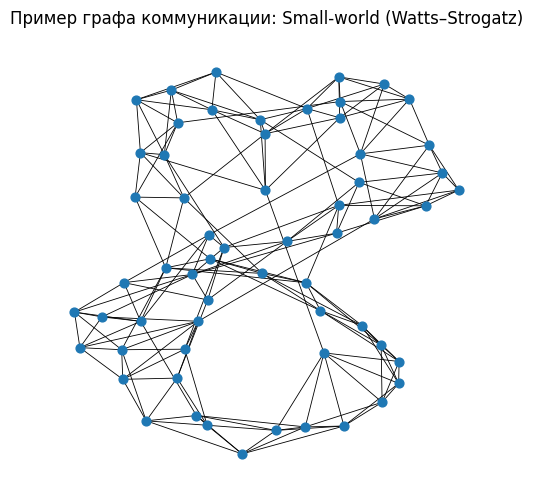

In [17]:

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def compute_graph_statistics(G: nx.Graph) -> dict:
    """Ключевые сетевые характеристики для distributed optimization."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    components = nx.number_connected_components(G)

    if nx.is_connected(G):
        diameter = nx.diameter(G)
        avg_path_len = nx.average_shortest_path_length(G)
    else:
        diameter = None
        avg_path_len = None

    # λ2 нормализованного лапласиана (spectral gap)
    L = nx.normalized_laplacian_matrix(G).toarray()
    evals = np.linalg.eigvalsh(L)
    evals.sort()
    lambda_2 = float(evals[1]) if len(evals) > 1 else None

    return {
        "Вершины": n,
        "Рёбра": m,
        "Компоненты": components,
        "Диаметр": diameter,
        "Средняя длина пути": avg_path_len,
        "λ₂": lambda_2,
    }


# 1) Генерируем графы (одинаковый размер для честного сравнения)
n = 60
graphs = {
    "Кольцо (Ring)": nx.cycle_graph(n),
    "Решётка 6×10 (Grid)": nx.grid_2d_graph(6, 10),
    "Случайный ER (p=0.08)": nx.erdos_renyi_graph(n, 0.08, seed=0),
    "Scale-free BA (m=2)": nx.barabasi_albert_graph(n, 2, seed=0),
    "Small-world WS (k=6, p=0.1)": nx.watts_strogatz_graph(n, 6, 0.1, seed=0),
}


# 2) Считаем статистики и печатаем КОРОТКО (чтобы не резалось)
print("Сравнение характеристик графов коммуникации (n=60):\n")

header = f"{'Граф':28s} | {'D':>3s} | {'L̄':>6s} | {'λ₂':>10s} | {'рёбра':>5s}"
print(header)
print("-" * len(header))

for name, G in graphs.items():
    s = compute_graph_statistics(G)
    D = "-" if s["Диаметр"] is None else str(s["Диаметр"])
    Lbar = "-" if s["Средняя длина пути"] is None else f"{s['Средняя длина пути']:.3f}"
    lam2 = "-" if s["λ₂"] is None else f"{s['λ₂']:.6f}"
    print(f"{name:28s} | {D:>3s} | {Lbar:>6s} | {lam2:>10s} | {s['Рёбра']:>5d}")


# 3) Визуализация: рисуем один граф (без tight_layout -> без warning)
fig, ax = plt.subplots(figsize=(6, 6))
G_vis = graphs["Small-world WS (k=6, p=0.1)"]
pos = nx.spring_layout(G_vis, seed=0)

nx.draw(G_vis, pos=pos, node_size=40, width=0.6, ax=ax)
ax.set_title("Пример графа коммуникации: Small-world (Watts–Strogatz)")
plt.show()


# Тестовая задача: Horizontal Federated Learning (консенсус)

**Цель.** Сравнить две эквивалентные математические формулировки одной и той же задачи
и посмотреть, как форма записи влияет на сходимость алгоритмов
на разных графах коммуникации.

## Базовая задача

Рассматривается система из $n$ агентов.
У агента с номером $i$ есть локальная функция
$$
f_i(x)=\tfrac12\|x-b_i\|^2,
$$
где $x\in\mathbb{R}^d$ — оптимизируемый вектор,
а $b_i\in\mathbb{R}^d$ — локальные данные агента.

Задача консенсуса имеет вид
$$
\min_{x_1,\dots,x_n}\ \sum_{i=1}^n f_i(x_i)
\quad\text{при условии}\quad
x_1=x_2=\dots=x_n,
$$
где $x_i$ — локальная копия решения у агента $i$.
Это простейшая модель Horizontal Federated Learning.

## Две формы записи

**1. Прямая форма (global consensus).**  
Условие согласования задаётся явно:
$$
x_1=x_2=\dots=x_n.
$$
Интерпретация: все локальные переменные должны совпасть.

**2. Форма по рёбрам графа (edge / coupled constraints).**  
Пусть задан граф коммуникации $G=(V,E)$,
где вершины $V$ — агенты, а рёбра $E$ — допустимые каналы связи.
Тогда консенсус можно записать как
$$
x_i-x_j=0\quad\forall (i,j)\in E.
$$
В матричном виде это записывается как
$$
Ax=0,
$$
где $x=(x_1,\dots,x_n)$ — вектор всех локальных переменных,
а матрица $A$ определяется структурой графа $G$
(по сути, это матрица разностей вдоль рёбер).

## Что проверяем

В статье показано, что сложность решения задач вида (P)
зависит не только от функций $f_i$,
но и от свойств матрицы ограничений $A$
и графа коммуникации.

Мы проверяем на практике,
может ли **эквивалентная форма записи ограничений**
приводить к разной скорости сходимости алгоритмов
и как этот эффект зависит от топологии графа.


In [18]:
import numpy as np

def generate_consensus_problem(n_agents=60, dim=5, seed=42):
    """
    Генерация простой квадратичной задачи консенсуса
    (toy example для Horizontal Federated Learning).

    f_i(x) = 1/2 * ||x - b_i||^2
    """
    rng = np.random.default_rng(seed)

    # Локальные данные агентов b_i
    b = rng.standard_normal(size=(n_agents, dim)) * 2.0  # shape: [n_agents, dim]

    # Аналитическое решение задачи консенсуса:
    # x* = (1/n) * sum_i b_i
    x_optimal = b.mean(axis=0)

    return b, x_optimal


# Генерируем тестовую задачу
b, x_opt = generate_consensus_problem()

print(f"Сгенерирована задача консенсуса:")
print(f"  число агентов n = {b.shape[0]}")
print(f"  размерность решения d = {b.shape[1]}")
print(f"  первые компоненты оптимального решения x*: {x_opt[:3]} ...")


Сгенерирована задача консенсуса:
  число агентов n = 60
  размерность решения d = 5
  первые компоненты оптимального решения x*: [-0.00183497 -0.1225728  -0.06832767] ...


Итераций: 200
Optimization error (||x̄ - x*||): 7.830e-15
Consensus error (avg ||x_i - x̄||): 1.456e+00


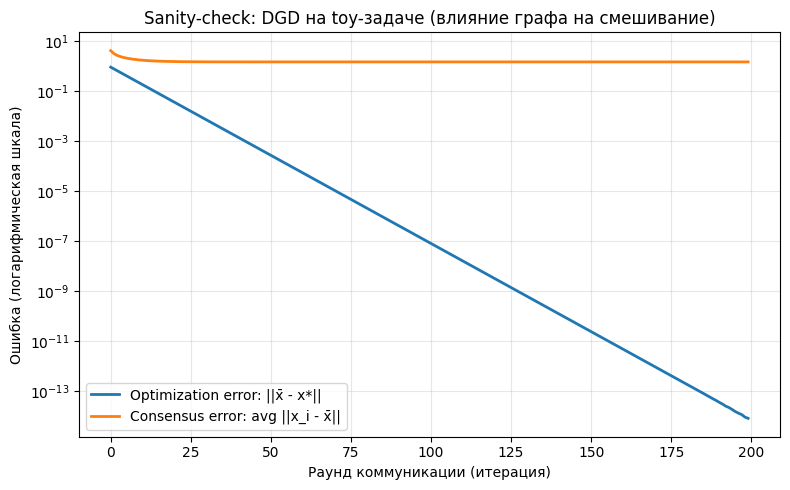

In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def metropolis_weights(G: nx.Graph) -> np.ndarray:
    """
    Metropolis-Hastings weights for an undirected graph.
    Gives a symmetric row-stochastic mixing matrix W.
    """
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    deg = dict(G.degree())
    W = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in G.neighbors(i):
            W[i, j] = 1.0 / (1.0 + max(deg[i], deg[j]))

    for i in range(n):
        W[i, i] = 1.0 - W[i].sum()

    return W


def decentralized_gradient_descent_sanity(G, b, x_opt, steps=200, step_size=0.1, seed=0):
    """
    SANITY-CHECK: Decentralized Gradient Descent (DGD) for the quadratic consensus toy problem.

    This cell is NOT the main "two-formulations" comparison yet.
    Here we only illustrate how the communication graph affects mixing / consensus speed.
    """
    n, d = b.shape
    rng = np.random.default_rng(seed)
    x = rng.standard_normal(size=(n, d)) * 0.1

    W = metropolis_weights(G)

    opt_errors = []
    cons_errors = []

    for _ in range(steps):
        # local gradient step: grad f_i(x_i) = x_i - b_i
        x_local = x - step_size * (x - b)

        # communication (mixing)
        x = W @ x_local

        x_bar = x.mean(axis=0)

        # optimization error: ||x_bar - x*||
        opt_err = np.linalg.norm(x_bar - x_opt) / (np.linalg.norm(x_opt) + 1e-12)

        # consensus error: average ||x_i - x_bar||
        cons_err = np.mean(np.linalg.norm(x - x_bar, axis=1)) / (np.linalg.norm(x_bar) + 1e-12)

        opt_errors.append(opt_err)
        cons_errors.append(cons_err)

        if opt_err < 1e-8 and cons_err < 1e-8:
            break

    return np.array(opt_errors), np.array(cons_errors), x


# --- quick run on one graph ---
G_ws = graphs["Small-world WS (k=6, p=0.1)"]
opt_err, cons_err, x_final = decentralized_gradient_descent_sanity(
    G_ws, b, x_opt, steps=200, step_size=0.15, seed=0
)

print(f"Итераций: {len(opt_err)}")
print(f"Optimization error (||x̄ - x*||): {opt_err[-1]:.3e}")
print(f"Consensus error (avg ||x_i - x̄||): {cons_err[-1]:.3e}")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.semilogy(opt_err, linewidth=2, label="Optimization error: ||x̄ - x*||")
plt.semilogy(cons_err, linewidth=2, label="Consensus error: avg ||x_i - x̄||")
plt.xlabel("Раунд коммуникации (итерация)")
plt.ylabel("Ошибка (логарифмическая шкала)")
plt.title("Sanity-check: DGD на toy-задаче (влияние графа на смешивание)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Кольцо (Ring)                 : 300 итераций, opt_err=2.260e-16, cons_err=3.433e+00
Small-world WS (k=6, p=0.1)   : 300 итераций, opt_err=3.043e-16, cons_err=1.456e+00
Случайный ER (p=0.08)         : 300 итераций, opt_err=5.246e-16, cons_err=1.692e+00
Scale-free BA (m=2)           : 300 итераций, opt_err=9.262e-16, cons_err=3.077e+00


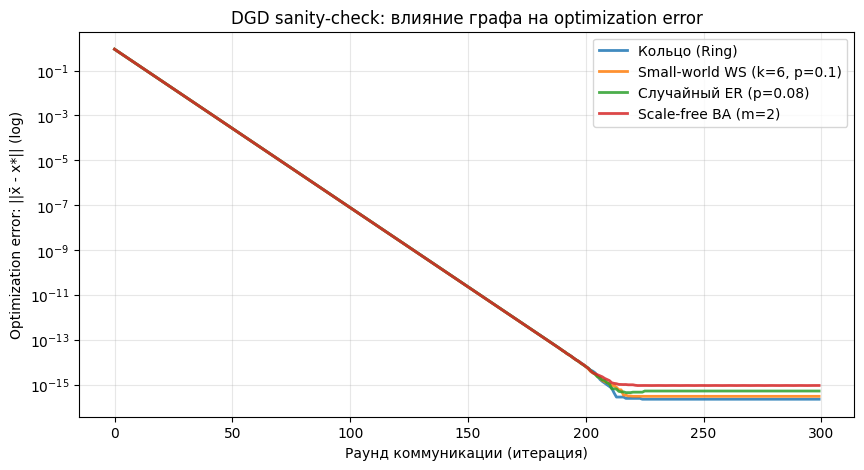

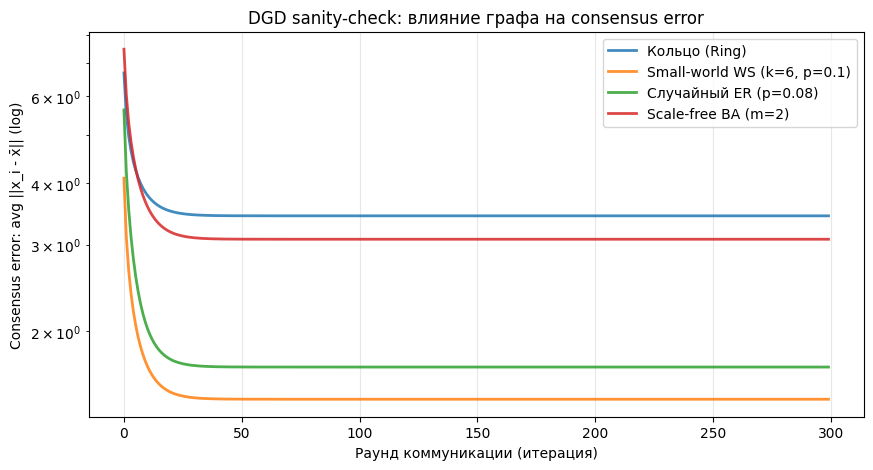


Сколько итераций нужно, чтобы достичь заданной точности
(показываем отдельно optimization error и consensus error)

Кольцо (Ring)
  < 1e-02:  opt =         29   cons = не достигнуто
  < 1e-03:  opt =         43   cons = не достигнуто
  < 1e-04:  opt =         58   cons = не достигнуто

Small-world WS (k=6, p=0.1)
  < 1e-02:  opt =         29   cons = не достигнуто
  < 1e-03:  opt =         43   cons = не достигнуто
  < 1e-04:  opt =         58   cons = не достигнуто

Случайный ER (p=0.08)
  < 1e-02:  opt =         29   cons = не достигнуто
  < 1e-03:  opt =         43   cons = не достигнуто
  < 1e-04:  opt =         58   cons = не достигнуто

Scale-free BA (m=2)
  < 1e-02:  opt =         29   cons = не достигнуто
  < 1e-03:  opt =         43   cons = не достигнуто
  < 1e-04:  opt =         58   cons = не достигнуто


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Графы для сравнения
selected_graphs = [
    "Кольцо (Ring)",
    "Small-world WS (k=6, p=0.1)",
    "Случайный ER (p=0.08)",
    "Scale-free BA (m=2)",
]

# Результаты: для каждого графа храним две кривые ошибок
results = {}

for name in selected_graphs:
    G = graphs[name]
    opt_err, cons_err, x_final = decentralized_gradient_descent_sanity(
        G, b, x_opt, steps=300, step_size=0.15, seed=0
    )
    results[name] = {"opt": opt_err, "cons": cons_err}

    print(
        f"{name:30s}: "
        f"{len(opt_err):3d} итераций, "
        f"opt_err={opt_err[-1]:.3e}, "
        f"cons_err={cons_err[-1]:.3e}"
    )

# --- График 1: optimization error (log scale) ---
plt.figure(figsize=(10, 5))
for name in selected_graphs:
    plt.semilogy(results[name]["opt"], linewidth=2, alpha=0.85, label=name)
plt.xlabel("Раунд коммуникации (итерация)")
plt.ylabel("Optimization error: ||x̄ - x*|| (log)")
plt.title("DGD sanity-check: влияние графа на optimization error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- График 2: consensus error (log scale) ---
plt.figure(figsize=(10, 5))
for name in selected_graphs:
    plt.semilogy(results[name]["cons"], linewidth=2, alpha=0.85, label=name)
plt.xlabel("Раунд коммуникации (итерация)")
plt.ylabel("Consensus error: avg ||x_i - x̄|| (log)")
plt.title("DGD sanity-check: влияние графа на consensus error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- Итерации до заданной точности ---
targets = [1e-2, 1e-3, 1e-4]

print("\n" + "=" * 80)
print("Сколько итераций нужно, чтобы достичь заданной точности")
print("(показываем отдельно optimization error и consensus error)")
print("=" * 80)

def iters_to_target(arr, target):
    idx = np.where(arr < target)[0]
    return None if len(idx) == 0 else int(idx[0] + 1)

for name in selected_graphs:
    opt = results[name]["opt"]
    cons = results[name]["cons"]

    print(f"\n{name}")
    for t in targets:
        a = iters_to_target(opt, t)
        b_ = iters_to_target(cons, t)
        a_str = f"{a}" if a is not None else "не достигнуто"
        b_str = f"{b_}" if b_ is not None else "не достигнуто"
        print(f"  < {t:.0e}:  opt = {a_str:>10s}   cons = {b_str:>10s}")
